In [8]:
import tensorflow as tf

# Load and prepare the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build a sequential model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

# Define the loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compile the model
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate performance on test data
model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9130 - loss: 0.2980
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9574 - loss: 0.1423
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9678 - loss: 0.1053
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9731 - loss: 0.0872
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9778 - loss: 0.0732
313/313 - 1s - 2ms/step - accuracy: 0.9765 - loss: 0.0783


[0.07825565338134766, 0.9764999747276306]

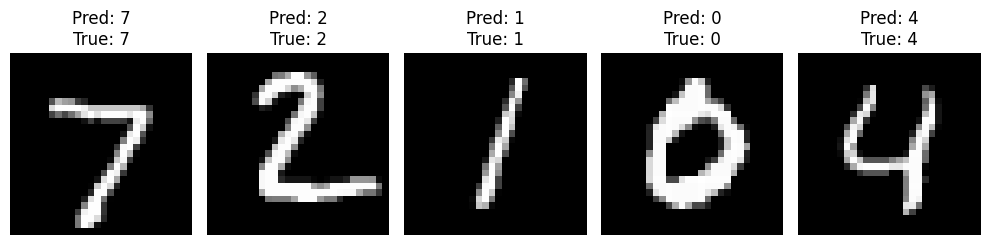

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on test images
predictions = tf.nn.softmax(model(x_test[:5])).numpy()

# Plot first 5 test images with predicted and actual labels
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i], cmap='gray')
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]
    ax.set_title(f"Pred: {predicted_label}\nTrue: {true_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Save model weights and architecture
model.save('mnist_model.keras')

# To load it back later:
# loaded_model = tf.keras.models.load_model('mnist_model.keras')